In [1]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from sklearn.datasets import make_swiss_roll
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *
from finsler_embedding.utils import *
from torchvision.ops import MLP
from finsler_embedding.omega import *


/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
def sample_sphere(N, radius=1.0):
    """
    Sample N points uniformly from the surface of a sphere with given radius.
    """
    phi = torch.rand(N) * 2 * torch.pi  # azimuthal angle
    costheta = torch.rand(N) * 2 - 1  # cos(theta) uniformly in [-1, 1]
    theta = torch.acos(costheta)  # polar angle

    x = radius * torch.sin(theta) * torch.cos(phi)
    y = radius * torch.sin(theta) * torch.sin(phi)
    z = radius * costheta
    return torch.stack((x, y, z), dim=1)

In [3]:
N = 2000
m = 2  # intrinsic dimension of the sphere (enters the kernel moments, m+2, m+3)
eps_scale = 10.0
beta=0.5

In [4]:
X = sample_sphere(N, radius=1.0)

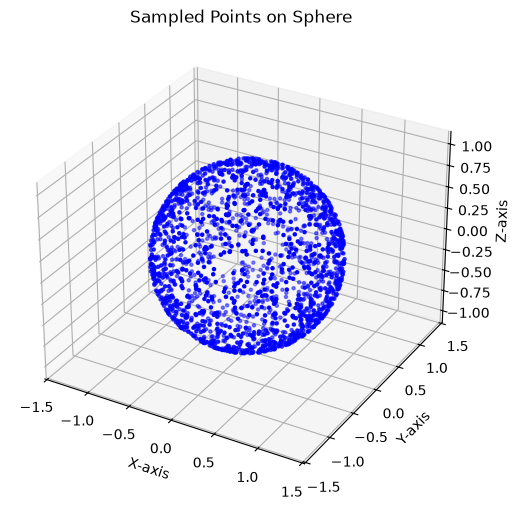

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='blue', s=5)
ax.set_title('Sampled Points on Sphere')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.axis('equal')
plt.show()

In [6]:
base_cometric = IdentityCoMetric()
# base_cometric = CentroidsCometric(centroids=X, cometric_centroids=base_cometric(X))
# omega_true = get_omega("swiss_roll", cometric=base_cometric,dim=3)
omega_true = get_omega("circular_sphere", cometric=base_cometric,dim=3)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=beta,
)

In [7]:
edges = get_knn_graph(X, n_neighbors=10,device="cpu")
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True)


[2026-09-21 15:53:29] - INFO - Found 22758 edges in the KNN graph.


Computing Randers distances: 100%|██████████| 228/228 [00:00<00:00, 5252.07it/s]


In [8]:
epsilon = compute_epsilon_empirical(dst_edges, scale=eps_scale)
W, _, _ = gaussian_kernel(edges, dst_edges, epsilon, N, m)

# Pure direction recovery

In [9]:
X_low = X.clone()

In [10]:
results = randers_approximation(W, epsilon, X_low=X_low, m=m)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

Loss: 0.0000: 100%|██████████| 2000/2000 [00:05<00:00, 365.00it/s]


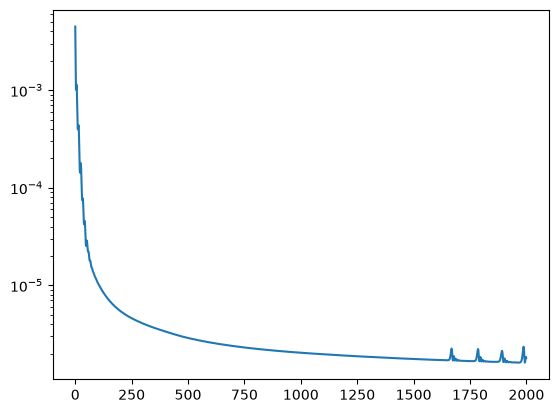

In [11]:
model, loss_list = interpolate_V(X_low, V, dim=m,n_epochs=2000)
# model, loss_list = interpolate_V(X_low, V_normed, dim=m, n_epochs=5000)
plt.plot(loss_list)
plt.yscale('log')

In [12]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone()
V_plt = V[idx].clone()
unit_V_plt = unit_V[idx].clone()

In [13]:
def fibonacci_sphere(n, device=None, dtype=torch.float32):
    i = torch.arange(n, device=device, dtype=dtype)

    golden_ratio = (1 + 5**0.5) / 2

    z = 1 - 2 * (i + 0.5) / n
    theta = 2 * torch.pi * i / golden_ratio

    r = torch.sqrt(1 - z**2)

    x = r * torch.cos(theta)
    y = r * torch.sin(theta)

    return torch.stack((x, y, z), dim=1)

# Around 500–1000 is usually plenty for visualization
X_sphere = fibonacci_sphere(1000)

with torch.no_grad():
    V_X = model(X_sphere)
    V_true = - omega_true(X_sphere) # Not the correct true formula but correct direction for Id metric

# Project to tangent space
V_X = V_X - (V_X * X_sphere).sum(dim=1, keepdim=True) * X_sphere
V_true = V_true - (V_true * X_sphere).sum(dim=1, keepdim=True) * X_sphere

# Normalize
V_X = V_X / (V_X.norm(dim=1, keepdim=True) + 1e-8)
V_true = V_true / (V_true.norm(dim=1, keepdim=True) + 1e-8)

In [14]:
u = np.linspace(0, 2*np.pi, 120)
v = np.linspace(0, np.pi, 60)

xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
theta = np.linspace(0, 2*np.pi, 300)

elev = 25
azim = 35


# Camera direction in Cartesian coordinates
elev_rad = np.deg2rad(elev)
azim_rad = np.deg2rad(azim)

camera = np.array([
    np.cos(elev_rad) * np.cos(azim_rad),
    np.cos(elev_rad) * np.sin(azim_rad),
    np.sin(elev_rad),
])


skip = 1

X_plt = X_sphere.cpu().numpy()[::skip]
V = V_X.cpu().numpy()[::skip]
V_true_plt = V_true.cpu().numpy()[::skip]

# Which side of the sphere faces the camera?
depth = X_plt @ camera
depth_samples = X_low @ camera
# Make front-facing arrows darker and back-facing arrows lighter
# (matplotlib accepts an array of RGB colors)
colors = np.empty((len(X_plt), 4))
colors_x_samples = np.empty((len(X_low), 4))

front = depth > 0
front_samples = depth_samples > 0
colors[front] = [0.05, 0.05, 0.05, 1.0]
colors[~front] = [0.5, 0.35, 0.35, .30]
colors_x_samples[front_samples] = [0.05, 0.05, 0.05, 1.0]
colors_x_samples[~front_samples] = [0.5, 0.35, 0.35, .30]

/tmp/ipykernel_2176835/3206554743.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  depth_samples = X_low @ camera


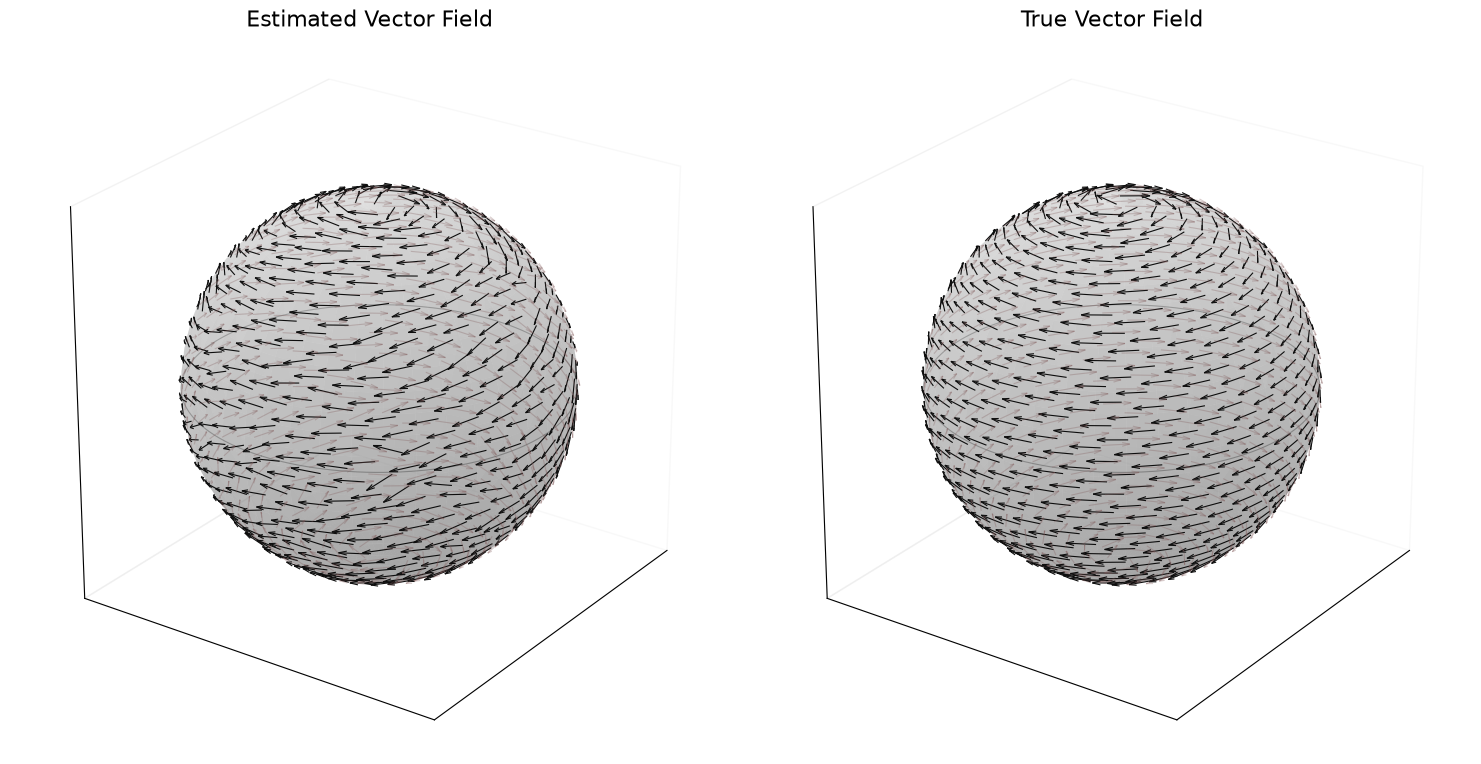

In [15]:


fig = plt.figure(figsize=(2*7.5, 7.5))

ax_est = fig.add_subplot(121, projection="3d")
ax_est.plot_surface(
    xs, ys, zs,
    color="0.85",
    alpha=0.30,
    linewidth=0,
    antialiased=True,
    shade=True,
)

# ax_est.scatter(X_low[:, 0], X_low[:, 1], X_low[:, 2], s=5,cmap=colors_x_samples[:])
# Sphere outline / equator
ax_est.plot(
    np.cos(theta),
    np.sin(theta),
    np.zeros_like(theta),
    color="0.45",
    linewidth=0.8,
    alpha=0.7,
)
ax_est.quiver(
    X_plt[:, 0], X_plt[:, 1], X_plt[:, 2],
    V[:, 0], V[:, 1], V[:, 2],
    length=0.15,
    normalize=True,
    linewidth=0.8,
    arrow_length_ratio=0.28,
    color=colors[::skip]
)
ax_true = fig.add_subplot(122, projection="3d")
ax_true.plot_surface(
    xs, ys, zs,
    color="0.85",
    alpha=0.30,
    linewidth=0,
    antialiased=True,
    shade=True,
)
# Sphere outline / equator
ax_true.plot(
    np.cos(theta),
    np.sin(theta),
    np.zeros_like(theta),
    color="0.45",
    linewidth=0.8,
    alpha=0.7,
)
ax_true.quiver(
    X_plt[:, 0], X_plt[:, 1], X_plt[:, 2],
    V_true_plt[:, 0], V_true_plt[:, 1], V_true_plt[:, 2],
    length=0.15,
    normalize=True,
    linewidth=0.8,
    arrow_length_ratio=0.28,
    color=colors[::skip]
)

# ------------------------------------------------------------
# Axes / camera
# ------------------------------------------------------------
for ax in [ax_est, ax_true]:
    ax.set_box_aspect((1, 1, 1))

    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.08, 1.08)
    ax.set_zlim(-1.08, 1.08)

    # Perspective gives a much stronger depth cue
    ax.set_proj_type("persp")

    ax.view_init(elev=elev, azim=azim)

    # Remove panes but retain a little structure
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.grid(False)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

ax_est.set_title("Estimated Vector Field", fontsize=16)
ax_true.set_title("True Vector Field", fontsize=16)

plt.tight_layout()
plt.show()

# Embeddings

In [16]:
X_low = Isomap(n_components=2, n_neighbors=10).fit_transform(X.cpu().numpy())
X_low = torch.from_numpy(X_low).float()
bounds = get_bounds(X_low,margin=0.1)

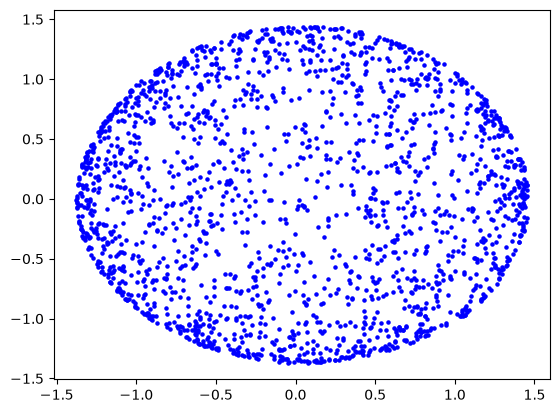

In [17]:
plt.scatter(X_low[:, 0], X_low[:, 1], c='blue', s=5)

In [18]:
results = randers_approximation(W, epsilon, X_low=X_low, m=m)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

  0%|          | 0/2000 [00:00<?, ?it/s]

Loss: 0.0000: 100%|██████████| 2000/2000 [00:04<00:00, 419.85it/s]


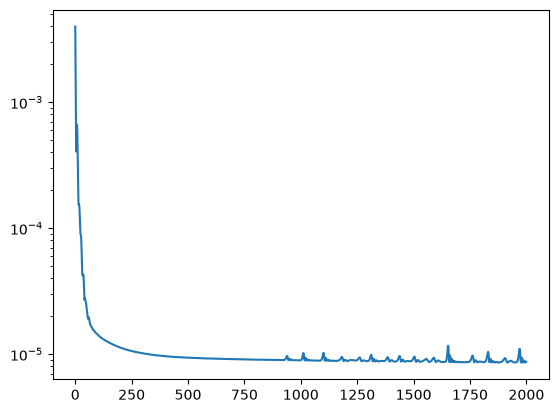

In [19]:
model, loss_list = interpolate_V(X_low, V, dim=2,n_epochs=2000)
# model, loss_list = interpolate_V(X_low, V_normed, dim=m, n_epochs=5000)
plt.plot(loss_list)
plt.yscale('log')

In [20]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone()
V_plt = V[idx].clone()
unit_V_plt = unit_V[idx].clone()

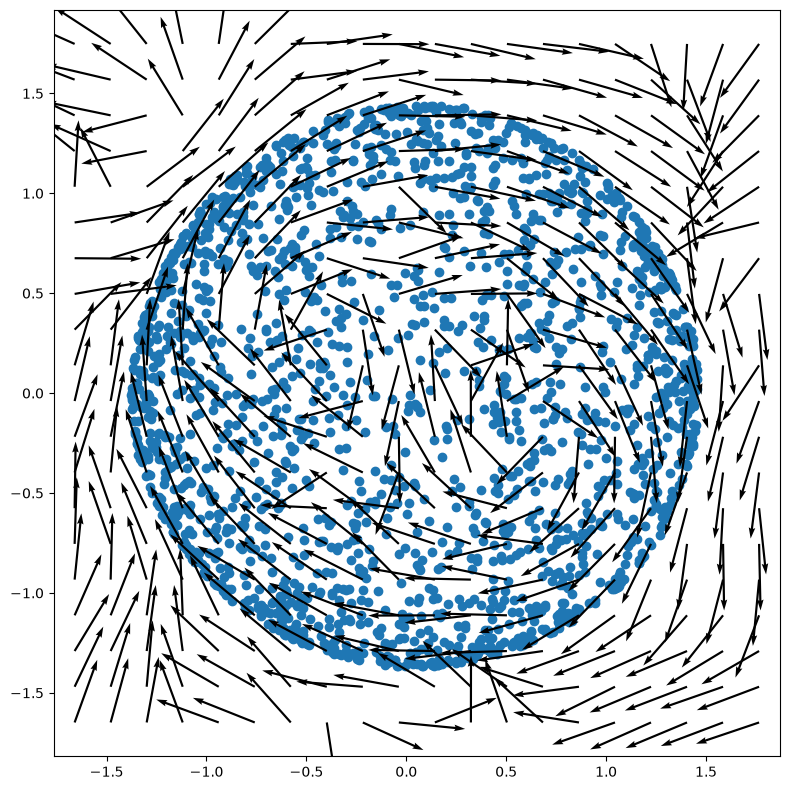

In [21]:
# Grid
x = torch.linspace(bounds[0], bounds[1], 20)
y = torch.linspace(bounds[2], bounds[3], 20)
X, Y = torch.meshgrid(x, y, indexing="ij")
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
# grid_points += 1e-1 * torch.randn_like(grid_points)
V_grid = model(grid_points).detach()
V_grid_unit = V_grid / (V_grid.norm(dim=1, keepdim=True) + 1e-12)

plt.figure(figsize=(8, 8))
plt.scatter(X_low[:, 0], X_low[:, 1])
plt.quiver(
    grid_points[:, 0],
    grid_points[:, 1],
    V_grid_unit[:, 0],
    V_grid_unit[:, 1],
    color="black",
    scale=3,
    angles="xy",
    scale_units="xy",
)
plt.xlim(bounds[0], bounds[1])
plt.ylim(bounds[2], bounds[3])
plt.tight_layout()
plt.axis("equal")
plt.show()